# 성적 데이터 분석

- 데싸고등학교 1학년의 중간고사 성적이 나왔습니다.
- 1반과 2반 두개의 반으로 구성되어 있고, 학생은 각각 6명입니다.
- 이 성적 데이터로 간단한 데이터 분석을 하고자 합니다.

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
df = pd.read_csv('score.csv')
df

,반,이름,국어,영어,수학,과학
0,1,성춘향,67,87,90,98
1,1,이몽룡,45,45,56,98
2,1,향단이,95,59,96,88
3,1,방자,65,94,89,98
4,1,월매,45,65,78,98
5,1,변학도,78,76,98,89
6,2,홍길동,87,67,65,56
7,2,임꺽정,89,98,78,78
8,2,전우치,100,78,56,65
9,2,일지매,99,89,87,87


- 여기에 기본적인 통계인 총점과 평균을 추가해서, 평균으로 정렬해보겠습니다.

In [4]:
subjects = ['국어', '영어', '수학', '과학']
df['총점'] = df[subjects].sum(axis=1)
df['평균']= df[subjects].mean(axis=1)
df.sort_values(['평균'], ascending=[False])

,반,이름,국어,영어,수학,과학,총점,평균
9,2,일지매,99,89,87,87,362,90.50
3,1,방자,65,94,89,98,346,86.50
7,2,임꺽정,89,98,78,78,343,85.75
0,1,성춘향,67,87,90,98,342,85.50
5,1,변학도,78,76,98,89,341,85.25
2,1,향단이,95,59,96,88,338,84.50
11,2,콩쥐,65,89,87,78,319,79.75
8,2,전우치,100,78,56,65,299,74.75
4,1,월매,45,65,78,98,286,71.50
6,2,홍길동,87,67,65,56,275,68.75


In [5]:
# 그래프 한글깨짐 방지 코드, 원인 : 디폴트 영문글꼴 ==> 한글글꼴
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin': # 맥OS
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# - 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

- 자료를 평균으로 내림차순 정렬하고, 각 데이터의 이름을 `이름` 필드를 사용하도록 한 후, 막대그래프를 그려봅니다. 

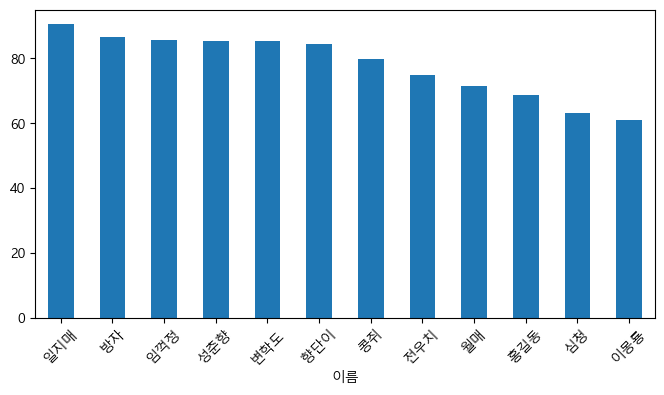

In [6]:
sorted_df = df.sort_values(['평균'], ascending=[False])
sorted_df.index = sorted_df['이름']
sorted_df['평균'].plot(kind='bar', figsize=(8, 4), rot=45);

- 막대그래프로 평균점수를 보니까, 2위 그룹들이 비슷비슷하네요.
- 일지매는 방심하면 안되겠네요.

## 1반과 2반의 점수 비교

그럼 이번에는 1반과 2반중 어느반이 더 잘했나 볼까요? 담임선생님들 이것에 민감하죠?

In [7]:
ban1 = df[df['반'] == 1]
ban2 = df[df['반'] == 2]
ban1_mean = ban1['평균'].mean()
ban2_mean = ban2['평균'].mean()
ban1_mean, ban2_mean # (79.04166666666667, 77.125)

(79.04166666666667, 77.125)

- 1반이 평균이 높네요.
- 1반 선생님 좋아합니다. 그걸 보고있던 2반 선생님이 "별 차이도 안나는구먼 뭘" 이라고 합니다. 

- 정말 두 반의 평균은 차이가 없는 걸까요?
- 서로 독립적인 두 집단에서 얻어진 수치형 자료로 부터 두 집단의 차이가 유의한지를 파악하는데는 독립표본 [t-검정](https://en.wikipedia.org/wiki/Student%27s_t-test) (two independent sample t-test)이 유용합니다.
- scipy의 ttest_ind 함수를 이용하여 바로 계산이 가능합니다.

In [8]:
from scipy import stats

In [9]:
stats.ttest_ind(ban1['평균'], ban2['평균'])

TtestResult(statistic=0.319960228209846, pvalue=0.7555833361856389, df=10.0)

- `p value > 0.005` 이므로 두 집단이 차이가 없다는 영가설을 채택합니다.
- 즉 1반과 2반은 사실 유의한 점수차이가 없습니다. 오차수준에 의한 차이라고 봐야겠네요. 1반 선생님 그렇게 좋아하시면 아니될 듯.

- 혹시 과목별로는 차이가 있을까요? 과목별로도 확인해보겠습니다.

In [10]:
for subject in subjects:
    print(subject, stats.ttest_ind(ban1[subject], ban2[subject]))

국어 TtestResult(statistic=-2.490140665442242, pvalue=0.03198249498381643, df=10.0)
영어 TtestResult(statistic=-0.6156907152631581, pvalue=0.5518533781528808, df=10.0)
수학 TtestResult(statistic=1.4961318778859336, pvalue=0.16549584200790557, df=10.0)
과학 TtestResult(statistic=4.328442555331755, pvalue=0.001493197771173248, df=10.0)


- 과학 과목은 p value < 0.005 입니다. 차이가 많이 나네요. 평균이 어떻길래.

In [11]:
ban1['과학'].mean(), ban2['과학'].mean()
# (94.83333333333333, 69.66666666666667)

(94.83333333333333, 69.66666666666667)

- 역시 차이가 많이 났군요. 1반 학생들은 과학에 소질이 많은 것 같습니다. 

## 과목별 비교 

- 과목별로 다른 특징이 있는 것 같습니다.
- 먼저 전체 데이터를 막대그래프로 그려보겠습니다.
- 앞서 그렸던 성적별 막대그래프를 과목별로 각각 그려보겠습니다. 

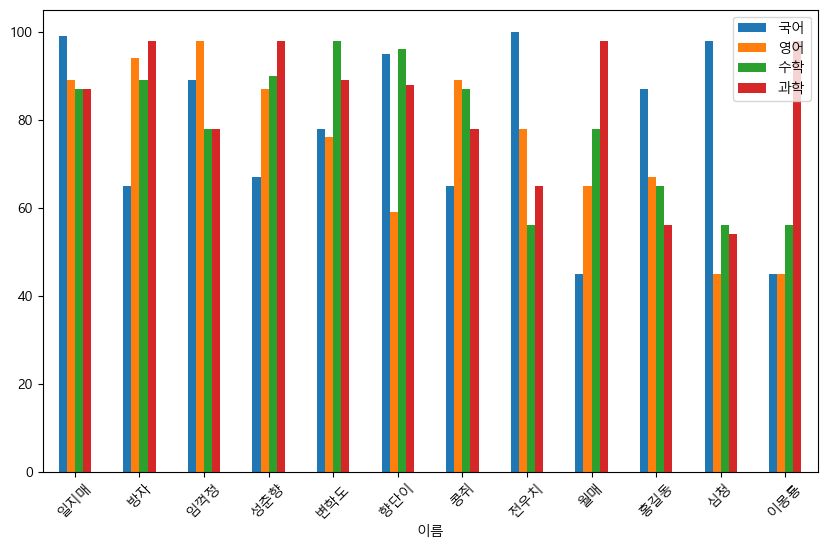

In [12]:
sorted_df[subjects].plot(kind='bar', figsize=(10, 6), rot=45);

- 일지매는 전체적으로 점수가 고르게 높은데, 2등부터는 약간 들쑥날쑥하네요.
- 과목별 점수 분포를 볼까요? boxplot으로 그려보겠습니다.

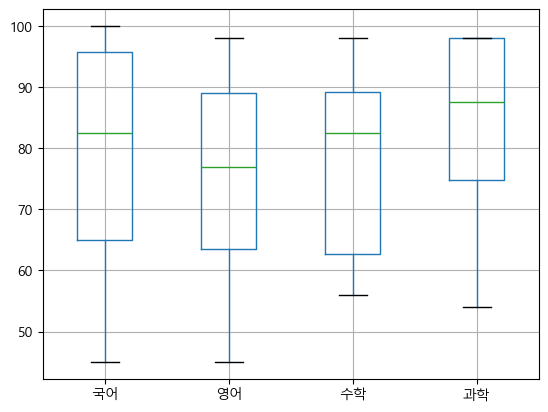

In [13]:
df[subjects].boxplot();

- 1반과 2반을 각각 boxplot으로 그려봅시다.

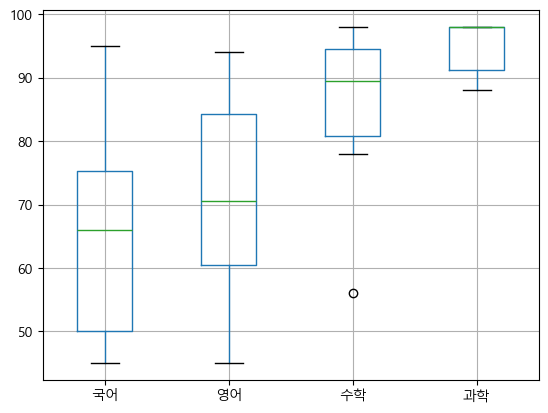

In [14]:
ban1[subjects].boxplot();

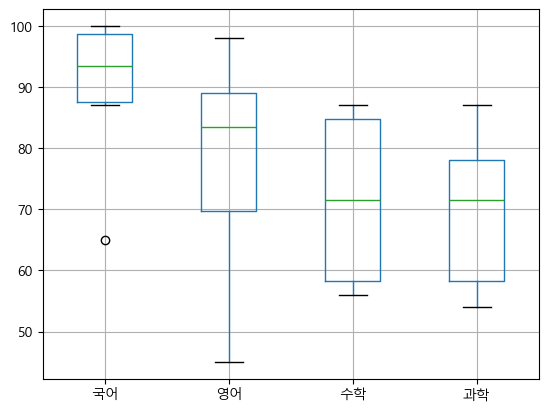

In [15]:
ban2[subjects].boxplot();

- 확실히, 1반의 과학점수가 좋네요. 분포 차이도 크지 않습니다.
- 대신 2반은 국어점수가 좋습니다.

## 과목별 상관도 

- 보통 수학 점수가 높으면 과학 점수가 높을 것이라고 기대할 수 있습니다.
- 국어 점수가 높으면 영어 점수가 높을 것이라고도 기대할 수 있죠.
- 언어능력, 수리능력이 별개의 특징처럼 생각될 수 도 있기 때문입니다.
- 여기 학생들도 그런지 살펴볼까요.

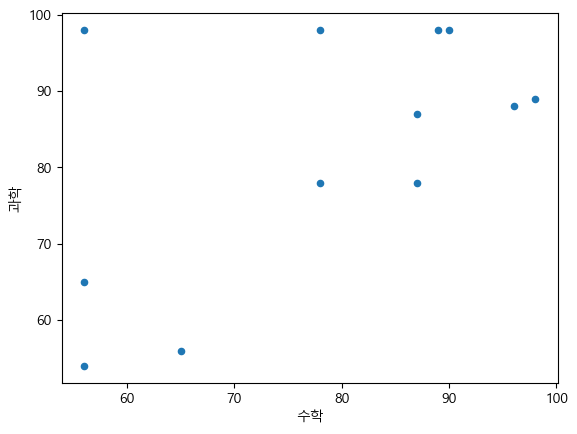

In [16]:
df.plot(kind='scatter', x='수학', y='과학');

- 수학점수가 높으면 과학점수도 높아 보입니다.
- 어느정도 상관관계가 보이네요. 얼마나 상관관계가 있을까요?
- 이럴때 상관계수를 구해볼 수 있습니다.
- [피어슨 상관계수](https://en.wikipedia.org/wiki/Pearson_product-moment_correlation_coefficient)를 구해볼까요?
- scipy의 stats 모듈에 함수가 있습니다. 

In [17]:
stats.pearsonr(df['수학'], df['과학'])

PearsonRResult(statistic=0.5632890597067751, pvalue=0.0565058048615552)

- 앞 숫자가 상관계수 뒷 숫자가 p-value를 의미합니다.
- 상관계수가 0.5보다 높으므로, 관계가 있긴 하지만 p > 0.05 이므로, 유의한 상관관계가 있지는 않네요.
- 데이터가 좀 더 많아지면, p-value가 의미있어지는 경우가 많습니다.
- 이 경우는 데이터 n수가 작아서 의미를 찾기 어려운 것 같습니다. 국어와 영어는 어떨까요?

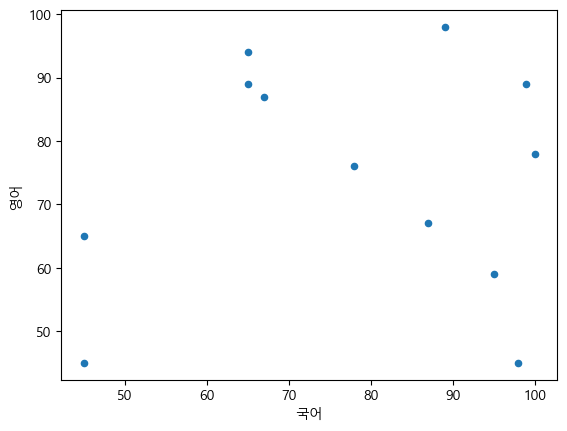

In [18]:
df.plot(kind='scatter', x='국어', y='영어');

In [19]:
stats.pearsonr(df['국어'], df['영어'])

PearsonRResult(statistic=0.10566562777973998, pvalue=0.7437959551857838)

- 상관관계가 아주 약간 있어보이지만 별로 없네요.
- 이 경우도, 데이터가 많으면 좀 더 충분한 관계를 밝혀낼 수 있을 것 같습니다. 

## 학생별 성적 패턴 분석

- 학생별로 어떤 학생은 수학을 잘하면서 과학을 잘하지만 영어는 약할 수 있고, 또 어떤 학생은 다른 패턴으로 잘하는 과목에 대한 특징이 있을 수 있습니다.
- 학생들끼리 이러한 성적 패턴이 얼마나 비슷한지 비교해 볼 수 있을까요?
- 이를 확인할 수 있는 다양한 방법이 있습니다.
- 대표적인 방법으로 [주성분분석 (Principle component analysis)](https://ko.wikipedia.org/wiki/주성분_분석)이 있습니다.
- 학생별로 4과목이라는 특성을 두개로 축약한 후, 2차원 평면에 표시하면, 그 종합적인 차이를 한눈에 알 수 있습니다. 
- PCA 분석은 [scikit-learn](http://scikit-learn.org/stable/)이라는 라이브러리를 설치하고 수행할 수 있습니다. 
- PCA 분석의 입력자료는 4과목의 성적데이터 입니다.

In [20]:
df[subjects]

,국어,영어,수학,과학
0,67,87,90,98
1,45,45,56,98
2,95,59,96,88
3,65,94,89,98
4,45,65,78,98
5,78,76,98,89
6,87,67,65,56
7,89,98,78,78
8,100,78,56,65
9,99,89,87,87


- 이 데이터를 정규화합니다.
- 전체 데이터를 최대, 최소를 기준으로 재 정리합니다.
- 정규화하는 함수는 scikit-learn 라이브러리에서 제공됩니다. 

In [21]:
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(df[subjects])
X_std

array([[-0.55809652,  0.72621778,  0.78954203,  1.01066629],
       [-1.70024754, -1.68176748, -1.44749373,  1.01066629],
       [ 0.89555023, -0.87910573,  1.18431305,  0.36897341],
       [-0.66192843,  1.12754865,  0.72374686,  1.01066629],
       [-1.70024754, -0.53510783,  0.        ,  1.01066629],
       [ 0.01297899,  0.09555497,  1.31590339,  0.43314269],
       [ 0.48022259, -0.42044187, -0.8553372 , -1.68444381],
       [ 0.5840545 ,  1.35688058,  0.        , -0.27271947],
       [ 1.15513001,  0.21022093, -1.44749373, -1.10692022],
       [ 1.10321405,  0.84088374,  0.59215653,  0.30480412],
       [ 1.0512981 , -1.68176748, -1.44749373, -1.81278239],
       [-0.66192843,  0.84088374,  0.59215653, -0.27271947]])

- 위 행렬데이터가 PCA의 입력으로 사용됩니다.
- PCA 분석 함수는 scikit-learn 라이브러리에 있습니다. 

In [22]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
Y = pca.fit_transform(X_std)
Y

array([[ 1.56591653,  0.09168753],
       [-0.11774518, -2.93515218],
       [ 0.20727166,  0.38845514],
       [ 1.71984653,  0.24234692],
       [ 1.11185524, -1.70512415],
       [ 1.03327136,  0.43547978],
       [-1.88205338,  0.20323602],
       [ 0.10118555,  1.27408337],
       [-1.88020684,  0.64411706],
       [ 0.39554448,  1.36047251],
       [-2.98704605, -0.37256038],
       [ 0.7321601 ,  0.37295837]])

- `Y` 변수에 4과목(4차원)을 2차원으로 축약한 데이터 값이 저장됩니다.
- 보통 제1주성분, 제2주성분이라고도 합니다.
- 이를 원래 데이터(df)에 추가합니다.

In [23]:
pca_df = pd.DataFrame(Y)
pca_df.index = df.index
pca_df.columns = ['PC1', 'PC2']
df2 = pd.concat([df, pca_df], axis=1)
df2

,반,이름,국어,영어,수학,과학,총점,평균,PC1,PC2
0,1,성춘향,67,87,90,98,342,85.50,1.565917,0.091688
1,1,이몽룡,45,45,56,98,244,61.00,-0.117745,-2.935152
2,1,향단이,95,59,96,88,338,84.50,0.207272,0.388455
3,1,방자,65,94,89,98,346,86.50,1.719847,0.242347
4,1,월매,45,65,78,98,286,71.50,1.111855,-1.705124
5,1,변학도,78,76,98,89,341,85.25,1.033271,0.435480
6,2,홍길동,87,67,65,56,275,68.75,-1.882053,0.203236
7,2,임꺽정,89,98,78,78,343,85.75,0.101186,1.274083
8,2,전우치,100,78,56,65,299,74.75,-1.880207,0.644117
9,2,일지매,99,89,87,87,362,90.50,0.395544,1.360473


- 위 데이터의 PC1, PC2 값으로 scatter plot을 그려봅니다.
- 1반과 2반의 차이를 알아보기 위해, 각각을 그룹핑하고, 다른 색으로 표시합니다. 

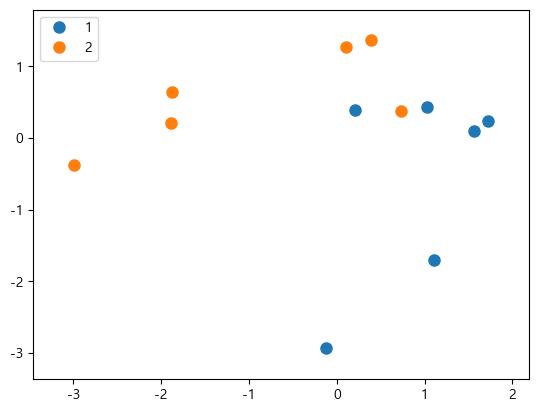

In [24]:
def draw_groups(groups, loc):
    fig, ax = plt.subplots()
    ax.margins(0.1)

    for name, group in groups:
        ax.plot(group['PC1'], group['PC2'], marker='o', linestyle='', ms=8, label=name)

    ax.legend(numpoints=1, loc=loc)

draw_groups(df2.groupby('반'), loc='upper left')

- 위 scatter plot에 의하면 `PC1 < 0, PC2 <0` 에 있는 7명의 학생이 어느 정도 비슷한 패턴을 갖는 것으로 보입니다.
- 이후, 교육 방침을 정하거나, 장래 희망 상담등을 할 때, 이 결과를 이용할 수 있을 것으로 보입니다.  

- 여기까지, 성적 데이터 분석을 통한 데이터 분석 사례 소개를 마칩니다.
- 이 예제는 성적이지만, 실제 실무적으로 유사한 데이터가 많습니다.
- 이들을 분석하는데 도움이 되시길 바랍니다.

In [25]:
# end